In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
data = pd.read_csv(
    "../data/processed/final_dataset.csv"
)

print("Dataset loaded!")
print("Shape:", data.shape)

Dataset loaded!
Shape: (2211, 23)


In [8]:
print(data.columns.tolist())

['title', 'address', 'city', 'price', 'bedroom', 'bathroom', 'floors', 'parking', 'face', 'year', 'views', 'area', 'road', 'road_width', 'road_type', 'build_area', 'posted', 'amenities', 'year_missing', 'road_width_ft', 'area_sqft', 'build_area_sqft', 'price_category']


In [9]:
features = [
    "bedroom",
    "bathroom",
    "floors",
    "parking",
    "year",
    "road_width_ft",
    "area_sqft",
    "build_area_sqft"
]

target = "price_category"

In [10]:
model_data = data[
    features + [target]
].dropna()

print("Model dataset shape:", model_data.shape)

Model dataset shape: (420, 9)


In [11]:
X = model_data[features]
y = model_data[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (420, 8)
Target shape: (420,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 336
Testing samples: 84


In [13]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [ ]:
y_pred_dt = dt_model.predict(X_test)

print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test, y_pred_dt)
)


Decision Tree Accuracy: 0.5119047619047619


In [29]:
import os
import joblib

# Create models folder
os.makedirs("../models", exist_ok=True)

# Save model
joblib.dump(
    dt_model,
    "../models/decision_tree_model.pkl"
)

print("Decision Tree model saved successfully!")
print("Location: ../models/decision_tree_model.pkl")

Decision Tree model saved successfully!
Location: ../models/decision_tree_model.pkl


In [30]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (420, 8)
y shape: (420,)
Features:
['bedroom', 'bathroom', 'floors', 'parking', 'year', 'road_width_ft', 'area_sqft', 'build_area_sqft']

Target:
price_category


In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import joblib
import os

# Train final Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

# Prediction
y_pred = dt_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy)
print("Decision Tree Accuracy: {:.2%}".format(accuracy))

Decision Tree Accuracy: 0.44047619047619047
Decision Tree Accuracy: 44.05%


In [32]:
print("X shape:", X.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

X shape: (420, 8)

Features:
['bedroom', 'bathroom', 'floors', 'parking', 'year', 'road_width_ft', 'area_sqft', 'build_area_sqft']

Target distribution:
price_category
High       144
Premium    121
Low        112
Medium      43
Name: count, dtype: int64

Target percentage:
price_category
High       34.285714
Premium    28.809524
Low        26.666667
Medium     10.238095
Name: proportion, dtype: float64


In [33]:
print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())


Training shape: (336, 8)
Testing shape: (84, 8)

Training target:
price_category
High       115
Premium     97
Low         90
Medium      34
Name: count, dtype: int64

Testing target:
price_category
High       29
Premium    24
Low        22
Medium      9
Name: count, dtype: int64


In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Decision Tree Accuracy:", accuracy)
print("Decision Tree Accuracy: {:.2%}".format(accuracy))

Decision Tree Accuracy: 0.44047619047619047
Decision Tree Accuracy: 44.05%


In [35]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

feature_names = X_train.columns.tolist()

model_package = {
    "model": dt_model,
    "features": feature_names
}

joblib.dump(
    model_package,
    "../models/decision_tree_package.pkl"
)

print("Model package saved successfully!")
print("Features used:")
print(feature_names)

Model package saved successfully!
Features used:
['bedroom', 'bathroom', 'floors', 'parking', 'year', 'road_width_ft', 'area_sqft', 'build_area_sqft']


In [36]:
loaded_package = joblib.load(
    "../models/decision_tree_package.pkl"
)

loaded_model = loaded_package["model"]
loaded_features = loaded_package["features"]

print("Model loaded successfully!")
print("Features:", loaded_features)

prediction = loaded_model.predict(X_test)

print("Prediction successful!")
print("Accuracy: {:.2%}".format(
    accuracy_score(y_test, prediction)
))

Model loaded successfully!
Features: ['bedroom', 'bathroom', 'floors', 'parking', 'year', 'road_width_ft', 'area_sqft', 'build_area_sqft']
Prediction successful!
Accuracy: 44.05%


In [15]:
print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

              precision    recall  f1-score   support

        High       0.68      0.52      0.59        29
         Low       0.35      0.27      0.31        22
      Medium       0.43      0.67      0.52         9
     Premium       0.52      0.67      0.58        24

    accuracy                           0.51        84
   macro avg       0.49      0.53      0.50        84
weighted avg       0.52      0.51      0.51        84



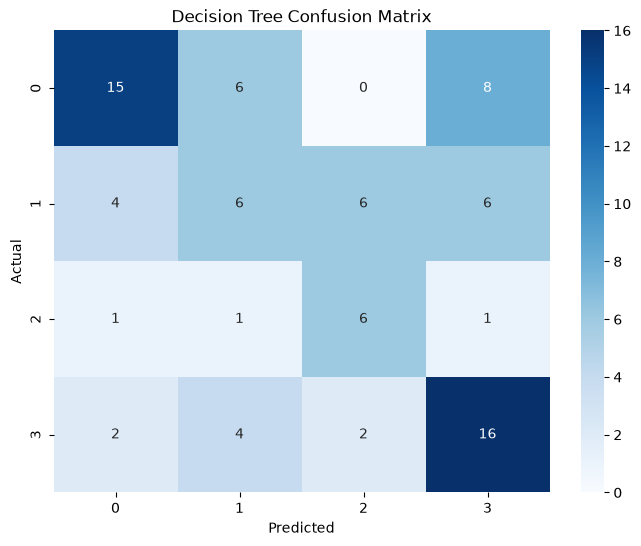

In [16]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../results/figures/decision_tree_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature scaling completed!")

Feature scaling completed!


In [18]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

print("KNN trained successfully!")

KNN trained successfully!


In [19]:
y_pred_knn = knn_model.predict(
    X_test_scaled
)

print(
    "KNN Accuracy:",
    accuracy_score(
        y_test,
        y_pred_knn
    )
)

KNN Accuracy: 0.4642857142857143


In [20]:
print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

              precision    recall  f1-score   support

        High       0.53      0.55      0.54        29
         Low       0.35      0.27      0.31        22
      Medium       0.36      0.56      0.43         9
     Premium       0.52      0.50      0.51        24

    accuracy                           0.46        84
   macro avg       0.44      0.47      0.45        84
weighted avg       0.46      0.46      0.46        84



In [21]:
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN"
    ],
    "Accuracy": [
        dt_accuracy,
        knn_accuracy
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,0.511905
1,KNN,0.464286


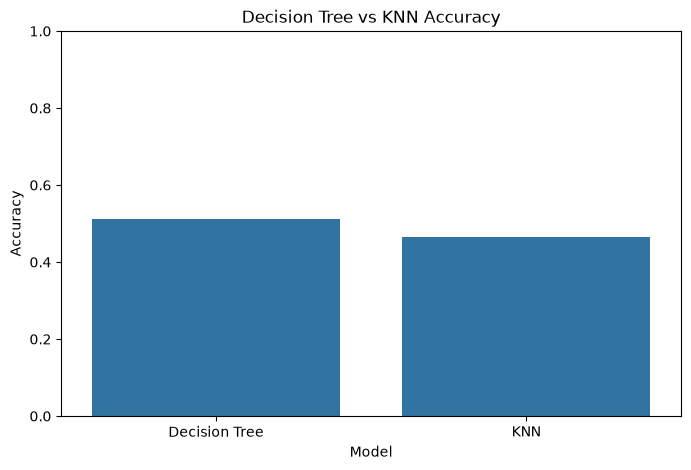

In [22]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Decision Tree vs KNN Accuracy"
)

plt.ylim(0, 1)

plt.savefig(
    "../results/figures/classification_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [23]:
import joblib

In [24]:
joblib.dump(
    dt_model,
    "../models/decision_tree.pkl"
)

['../models/decision_tree.pkl']

In [25]:
joblib.dump(
    knn_model,
    "../models/knn.pkl"
)

['../models/knn.pkl']

In [26]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, prediction in [
    ("Decision Tree", y_pred_dt),
    ("KNN", y_pred_knn)
]:
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(
            y_test, prediction, average="weighted"
        ),
        "Recall": recall_score(
            y_test, prediction, average="weighted"
        ),
        "F1-Score": f1_score(
            y_test, prediction, average="weighted"
        )
    })

comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.511905,0.521210,0.511905,0.505802
1,KNN,0.464286,0.463898,0.464286,0.460314
